In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'anaconda_projects', 'Titanic_ML_Project', 'train_data.csv']


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
AI_PROJECT_ANALYSIS= pd.read_csv('train_data.csv')
AI_PROJECT_ANALYSIS=AI_PROJECT_ANALYSIS.drop('Unnamed: 0',axis=1)
AI_PROJECT_ANALYSIS.head()

,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,1,0,1,0.2750,0.014151,0,0,1,0.1,1,0,0,0,0,0,1
1,2,1,0,0.4750,0.139136,1,0,0,0.1,1,0,0,0,1,0,0
2,3,1,0,0.3250,0.015469,0,0,1,0.0,0,0,0,1,0,0,1
3,4,1,0,0.4375,0.103644,1,0,0,0.1,1,0,0,0,0,0,1
4,5,0,1,0.4375,0.015713,0,0,1,0.0,1,0,0,0,0,0,1


In [21]:
AI_PROJECT_ANALYSIS.info()
AI_PROJECT_ANALYSIS.isnull().sum()
AI_PROJECT_ANALYSIS.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  792 non-null    int64  
 1   Survived     792 non-null    int64  
 2   Sex          792 non-null    int64  
 3   Age          792 non-null    float64
 4   Fare         792 non-null    float64
 5   Pclass_1     792 non-null    int64  
 6   Pclass_2     792 non-null    int64  
 7   Pclass_3     792 non-null    int64  
 8   Family_size  792 non-null    float64
 9   Title_1      792 non-null    int64  
 10  Title_2      792 non-null    int64  
 11  Title_3      792 non-null    int64  
 12  Title_4      792 non-null    int64  
 13  Emb_1        792 non-null    int64  
 14  Emb_2        792 non-null    int64  
 15  Emb_3        792 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 99.1 KB


,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
count,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000
mean,396.500000,0.386364,0.647727,0.368244,0.064677,0.243687,0.208333,0.547980,0.088636,0.744949,0.005051,0.040404,0.209596,0.185606,0.092172,0.720960
std,228.774999,0.487223,0.477980,0.162994,0.100987,0.429577,0.406373,0.498007,0.154485,0.436165,0.070932,0.197029,0.407277,0.389034,0.289451,0.448811
min,1.000000,0.000000,0.000000,0.008375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,198.750000,0.000000,0.000000,0.275000,0.015469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,396.500000,0.000000,1.000000,0.350000,0.028302,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,594.250000,1.000000,1.000000,0.437500,0.061045,0.000000,0.000000,1.000000,0.100000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,792.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
print(AI_PROJECT_ANALYSIS.columns.tolist())

['PassengerId', 'Survived', 'Sex', 'Age', 'Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Family_size', 'Title_1', 'Title_2', 'Title_3', 'Title_4', 'Emb_1', 'Emb_2', 'Emb_3']


In [28]:
X = AI_PROJECT_ANALYSIS.drop(['PassengerId' , 'Survived'], axis=1)
y = AI_PROJECT_ANALYSIS['Survived']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", confusion_matrix(y_test,predictions))

Accuracy: 0.8113207547169812

Classification Report:
 [[81 17]
 [13 48]]


In [40]:
import pandas as pd
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

Fare           0.253852
Age            0.220949
Sex            0.214114
Family_size    0.080875
Title_1        0.060520
Pclass_3       0.055904
Title_4        0.030920
Pclass_1       0.022272
Pclass_2       0.016416
Emb_3          0.013191
Emb_1          0.011293
Title_3        0.009693
Emb_2          0.009469
Title_2        0.000530
dtype: float64


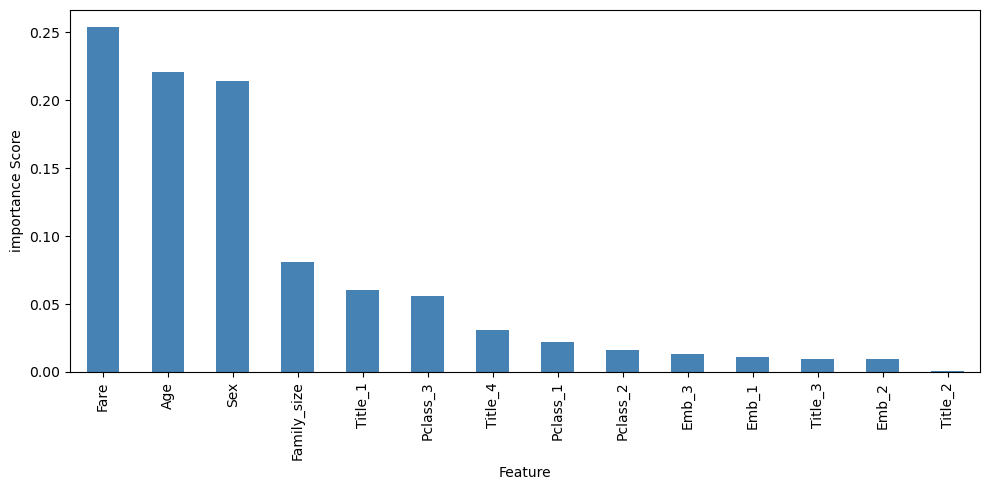

In [46]:
import matplotlib.pyplot as plt
importances.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.ylabel('importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()